In [1]:
import sys
sys.path.append('/app')
# unit_test/test_single_receptor.py
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np
import os
from itertools import cycle

from src import (generate_receptor_indices,
                generate_cascading_receptors,
                generate_targeted_receptors,
                plot_family_summary,                
                plot_latent_radar_chart,
                evaluate_model,
                plot_summary,
                plot_latent_umap)
from run import initialize,train,test

In [2]:
n_units=3
k_sub = 5
n_families = 1
N_train = 2**16
N_test = 2**14
CONF = {
        "n_units": n_units,
        "n_families": n_families,
        "latent_dim": 3,
        "k_sub": k_sub,
        "batch_size": N_train,
        "epochs": 5000,
        "lr": 0.05,
        "cov_weight":10.,
        "n_bins":2,
        "bin_temp":0.05,
        "receptor_indices":torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)],dtype=torch.long), # size must be smaller or equal to n_units
        "init_means":[np.random.randint(1,8) for _ in range(n_families)], # size must be n_families
        "shape_sigma": 1.,
        "tolerant":False, # set whether we want tolerance for heteromers on the covariance loss
        "optimizer":"Adam",
        "momentum":0.9,
        "exact_loss":True,
        "temperature":0.1
    }
n_sensors = np.arange(1,10,1)

In [3]:
train_stats = []
test_res = []
for n_units in n_sensors:
    CONF['n_units'] = n_units
    CONF['receptor_indices'] = torch.tensor([[i for _ in range(k_sub)] for i in range(n_units)],dtype=torch.long)
    env,rec,loss_fn,optimize = initialize(CONF,SymmetricEnv=False)
    train_stats.append(train(CONF,env,rec,loss_fn,optimize))
    test_res.append(test(CONF,env,rec,loss_fn,optimize,N_samples=N_test,indices = CONF['receptor_indices']))


Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...


Fitting UMAP... (This may take a few seconds)


(<Figure size 500x400 with 1 Axes>,
 <Axes: title={'center': 'UMAP Projection of 3D Chemical Latent Space'}, xlabel='UMAP Dimension 1', ylabel='UMAP Dimension 2'>)

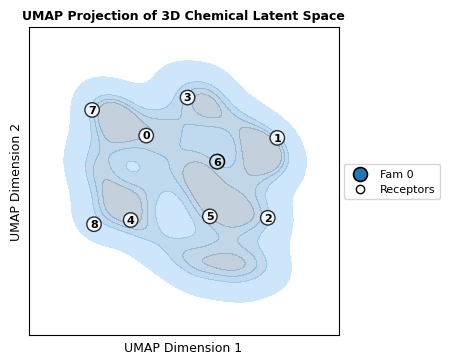

In [4]:
plot_latent_umap(env,CONF["receptor_indices"])

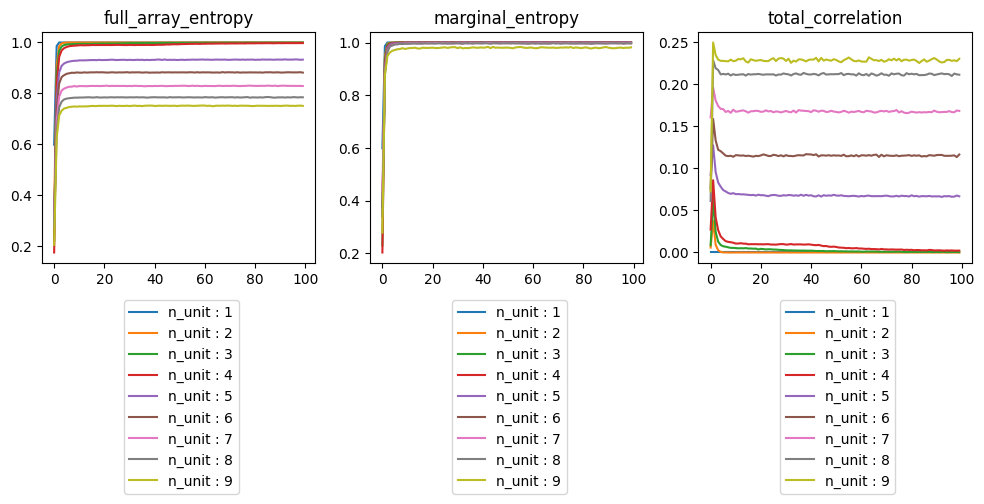

In [7]:
fig,ax = plt.subplots(ncols=3,figsize=(3*4,3))
for n,stat in enumerate(train_stats):
    for i,key in enumerate(stat.keys()):
        ax[i].plot(stat[key]/n_sensors[n],label=f'n_unit : {n_sensors[n]}')
        ax[i].set_title(key)

for i in range(3):
    ax[i].legend(loc=(0.3,-1.))

In [5]:
np.save('stat_homo.npy',stats)

In [4]:
generate_cascading_receptors(n_units=3, k_sub=CONF['k_sub'], n_sensors=1).shape

torch.Size([1, 5])

In [13]:
stats_h_3 = []
test_res_3 = []
CONF['n_units'] = 3
for n_sensor in n_sensors:
    CONF['receptor_indices'] = generate_cascading_receptors(n_units=CONF['n_units'], k_sub=CONF['k_sub'], n_sensors=n_sensor)
    env,rec,loss_fn,optimize = initialize(CONF,SymmetricEnv=False)
    stats_h_3.append(train(CONF,env,rec,loss_fn,optimize))
    test_res_3.append(test(CONF,env,rec,loss_fn,optimize,N_samples=N_test,indices = CONF['receptor_indices']))

Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...


In [10]:
stats_h_2 = []
test_res_2 = []
CONF['n_units'] = 2
for n_sensor in n_sensors:
    CONF['receptor_indices'] = generate_cascading_receptors(n_units=CONF['n_units'], k_sub=CONF['k_sub'], n_sensors=n_sensor)
    env,rec,loss_fn,optimize = initialize(CONF,SymmetricEnv=False)
    stats_h_2.append(train(CONF,env,rec,loss_fn,optimize))
    test_res_2.append(test(CONF,env,rec,loss_fn,optimize,N_samples=N_test,indices = CONF['receptor_indices']))

Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...


In [12]:
stats_h_4 = []
test_res_4 = []
CONF['n_units'] = 4
for n_sensor in n_sensors:
    CONF['receptor_indices'] = generate_cascading_receptors(n_units=CONF['n_units'], k_sub=CONF['k_sub'], n_sensors=n_sensor)
    env,rec,loss_fn,optimize = initialize(CONF,SymmetricEnv=False)
    stats_h_4.append(train(CONF,env,rec,loss_fn,optimize))
    test_res_4.append(test(CONF,env,rec,loss_fn,optimize,N_samples=N_test,indices = CONF['receptor_indices']))

Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...
Training for 5000 epochs...


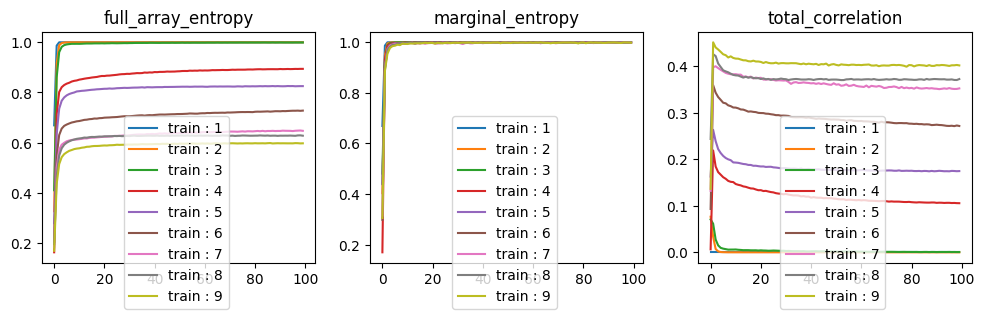

In [15]:
fig,ax = plt.subplots(ncols=3,figsize=(3*4,3))
for n,stat in enumerate(stats_h_3):
    for i,key in enumerate(stat.keys()):
        ax[i].plot(stat[key]/n_sensors[n],label=f'train : {n_sensors[n]}')
        ax[i].set_title(key)

for i in range(3):
    ax[i].legend(loc=(0.3,-.2))

In [19]:
tests_res = np.array([test_res,test_res_2,test_res_3,test_res_4])

np.save('ent_test.npy',tests_res)


In [20]:
tests_res = np.load('ent_test.npy')

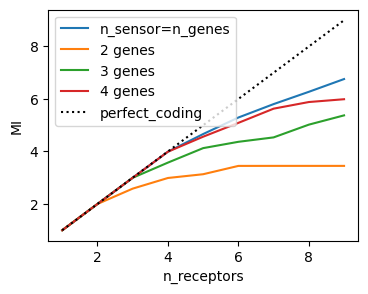

In [ ]:
fig,ax = plt.subplots(figsize=(4,3))
labels = ['n_sensor=n_genes','2 genes','3 genes','4 genes']
for i in range(4):
    ax.plot(n_sensors,np.mean(tests_res[i],axis=1), label = labels[i])
ax.plot(n_sensors,n_sensors,color='black',linestyle=':',label='perfect_coding')
ax.set_xlabel('n_receptors')
ax.set_ylabel('MI')
ax.legend()
#plt.savefig('MI_sensors.svg',transparent=True,bbox_inches='tight')